# Proyecto PSO — Optimización de Sensores de Riego
# Integrantes: Gutierrez Chavez Denzel Arturo   
#              Quiñonez Madrid Juan Carlos
En este proyecto vamos realizar un proyecto aplicado a la industria agrícola utilizando el algoritmo bio inspirado de Enjambre de Partículas (PSO). El objetivo es optimizar la ubicación de sensores en un campo agrícola para maximizar la eficiencia del riego

In [6]:
# Instalacion de librerias
# Aqui en esta parte vamos a señalar las librerias que seran utilizadas alrededor del proyecto, las que fueron propuestas por nuestro profesor
# y las que nosotros creemos que son necesarias
#  #necesitaremos la libreria PySwarms asi que la instalaremos
import pandas as pd          
import numpy as np           
from sklearn.preprocessing import MinMaxScaler  
from scipy.spatial.distance import cdist        
import pyswarms as ps   
import matplotlib.pyplot as plt   
import seaborn as sns             

import warnings
warnings.filterwarnings('ignore')


In [ ]:
#PARAMETROS PRINCIPALES Y CARGA DEL CSV DE DATOS 

RUTA_CSV = 'c:\Modulo 3\data\datos_cultivos_guasave.csv'

# aqui colocamos el numero de sensores que queremos optimizar, el numero de particulas en el enjambre y 
# el numero de iteraciones para la optimizacion
N_SENSORES = 5
N_PARTICULAS = 50
ITERACIONES = 100

# c1 = cognitivo: cuánto le hace caso cada partícula a su propio historial
# c2 = social:    cuánto le hace caso al mejor global del enjambre
# w  = inercia:   qué tanto mantiene su velocidad actual
OPCIONES_PSO = {
    'c1': 0.5,   # componente cognitiva
    'c2': 0.3,   # componente social
    'w' : 0.9    # inercia
}

# Semilla para que los resultados sean reproducibles
np.random.seed(42)

print('✅ Configuración cargada:')
print(f'   Archivo CSV   : {RUTA_CSV}')
print(f'   Sensores      : {N_SENSORES}')
print(f'   Partículas    : {N_PARTICULAS}')
print(f'   Iteraciones   : {ITERACIONES}')
print(f'   Parámetros PSO: {OPCIONES_PSO}')

✅ Configuración cargada:
   Archivo CSV   : c:\Modulo 3\data\datos_cultivos_guasave.csv
   Sensores      : 5
   Partículas    : 50
   Iteraciones   : 100
   Parámetros PSO: {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


In [ ]:
class CargadorDatos:
    """
    Esta clase lo que hace es cargar los datos desde el archivo CSV y preprocesarlos
    """

    def __init__(self, ruta_archivo):
        self.ruta_archivo             = ruta_archivo
        self.datos_originales         = None  
        self.datos_procesados         = None  
        self.escalador                = None  
        self.columnas_caracteristicas = None  
        
    def cargar_y_preprocesar(self):
        #Carga y preprocesa los datos

        print(f" Cargando datos desde '{self.ruta_archivo}'...")
        #Cargar datos con pandas
        self.datos_originales = pd.read_csv(self.ruta_archivo)

       # Aqui convertimos la columna 'Cultivo' en variables dummy (one-hot encoding)
        datos_codificados = pd.get_dummies(self.datos_originales, columns=['Cultivo'])
        # guardar nombres de columnas para referencia futura 
        self.columnas_caracteristicas = datos_codificados.columns

       #Escalamos los datos usando MinMaxScaler para que estén en el rango [0,1]
        self.escalador        = MinMaxScaler()
        self.datos_procesados = self.escalador.fit_transform(datos_codificados)
        print(f"Datos preprocesados con {self.datos_procesados.shape[1]} características:")
        print(list(self.columnas_caracteristicas))

        return self


cargador = CargadorDatos(RUTA_CSV)
cargador.cargar_y_preprocesar()

# Con esto ya tenemos los datos listos y cargados para pasar a la siguiente etapa


 Cargando datos desde 'c:\Modulo 3\data\datos_cultivos_guasave.csv'...
Datos preprocesados con 9 características:
['Humedad (%)', 'Elevación (m)', 'Salinidad (dS/m)', 'Temperatura (°C)', 'Latitud', 'Longitud', 'Cultivo_Chile', 'Cultivo_Maíz', 'Cultivo_Tomate']


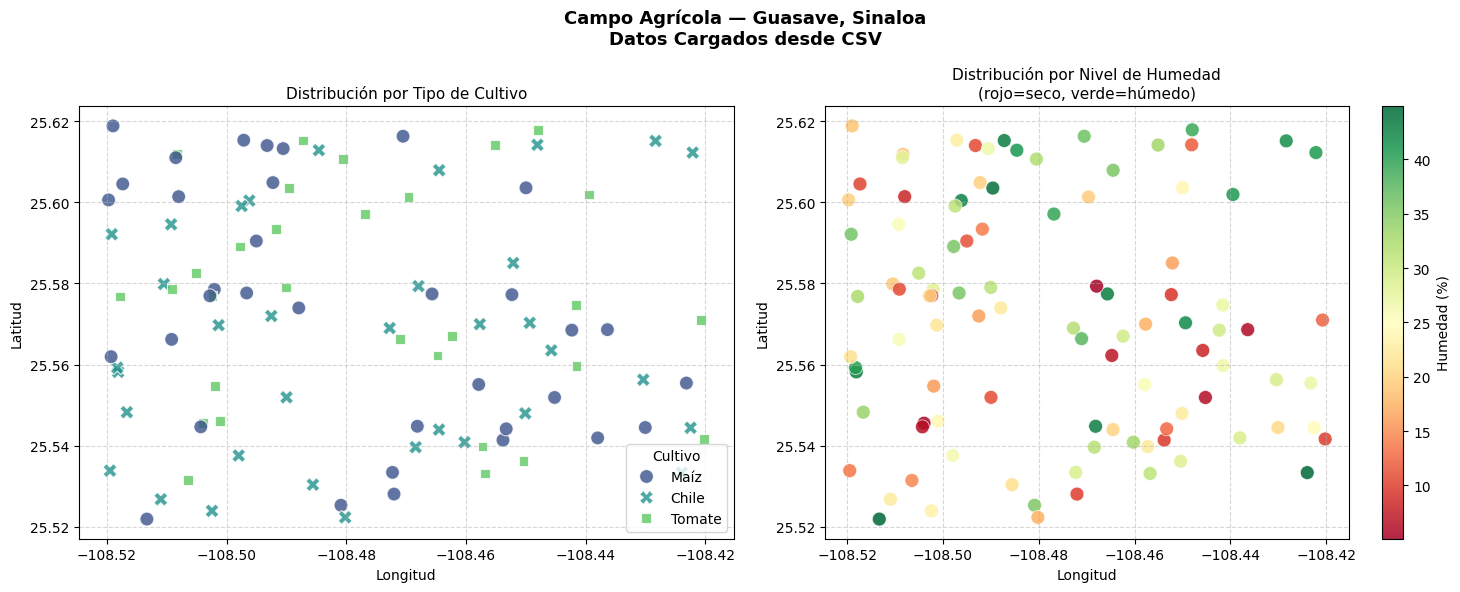

In [14]:
# Visualizacion de los datos originales
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Campo Agrícola — Guasave, Sinaloa\nDatos Cargados desde CSV',
             fontsize=13, fontweight='bold')

sns.scatterplot(
    data=cargador.datos_originales,
    x='Longitud', y='Latitud',
    hue='Cultivo', style='Cultivo',
    s=100, alpha=0.8,
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Distribución por Tipo de Cultivo', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

col_humedad = [c for c in cargador.datos_originales.columns if 'Humedad' in c][0]
sc = axes[1].scatter(
    cargador.datos_originales['Longitud'],
    cargador.datos_originales['Latitud'],
    c=cargador.datos_originales[col_humedad],
    cmap='RdYlGn', s=100, alpha=0.85,
    edgecolors='white', linewidths=0.5
)
plt.colorbar(sc, ax=axes[1], label=col_humedad)
axes[1].set_title('Distribución por Nivel de Humedad\n(rojo=seco, verde=húmedo)', fontsize=11)
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Con esta visualizacion, pasamos a la etapa de la optimizacion a partir del PSO, implementando el framework dado por el profesor
# el cual es PySwarms, una libreria de optimizacion por enjambre de particulas en Python.

""" QUE HACE PYSWARMS?
implementa el enjambre completo internamente.
Solo le pasamos:
- Cuántas partículas
- Cuántas dimensiones (N_sensores × N_columnas)
- Los parámetros c1, c2, w
- Los límites del espacio de búsqueda [0, 1]
- Nuestra función de costo

Y él solo se encarga de mover el enjambre y encontrar el mínimo."""

class OptimizadorSensoresPSO:
    
    def __init__(self, n_sensores, datos, n_particulas, iteraciones,
                 escalador, columnas_caracteristicas, opciones_pso):
        self.n_sensores              = n_sensores
        self.datos                   = datos
        self.n_particulas            = n_particulas
        self.iteraciones             = iteraciones
        self.escalador               = escalador
        self.columnas_caracteristicas= columnas_caracteristicas
        self.opciones_pso            = opciones_pso
        self.n_caracteristicas = datos.shape[1]
        self.n_dimensiones     = n_sensores * self.n_caracteristicas

        # Resultados de la optimización
        self.mejor_costo      = np.inf
        self.mejor_posicion   = None
        self.historial_costos = []

    def _funcion_costo_particula(self, posicion_particula):
        try:
            centroides = posicion_particula.reshape(
                self.n_sensores, self.n_caracteristicas
            )
        except ValueError as e:
            print(f"  Error de dimensiones: {e}")
            return np.inf

       # descubrimo que cdist calcula TODAS las distancias entre puntos y sensores de golpe
        distancias = cdist(self.datos, centroides, 'euclidean')
        min_distancias = np.min(distancias, axis=1)
        costo = np.sum(min_distancias ** 2)
        return costo

    def _funcion_costo_lote(self, lote_particulas):
        return np.array([
            self._funcion_costo_particula(p) for p in lote_particulas
        ])

    def ejecutar_optimizacion(self):
        """
        Configura y ejecuta el algoritmo PSO usando pyswarms.
        """
        print(f"  Partículas: {self.n_particulas} | "
              f"Iteraciones: {self.iteraciones} | "
              f"Parámetros: {self.opciones_pso}")

        # Límites: todas las dimensiones entre 0 y 1
        limite_inferior = np.zeros(self.n_dimensiones)
        limite_superior = np.ones(self.n_dimensiones)
        limites = (limite_inferior, limite_superior)

        optimizador = ps.single.GlobalBestPSO(
            n_particles = self.n_particulas,
            dimensions  = self.n_dimensiones,
            options     = self.opciones_pso,
            bounds      = limites
        )

        # aqui se puede notar que optimize() llama a _funcion_costo_lote en cada iteración
        self.mejor_costo, self.mejor_posicion = optimizador.optimize(
            self._funcion_costo_lote,
            iters   = self.iteraciones,
            verbose = True
        )

        self.historial_costos = optimizador.cost_history

    def obtener_ubicaciones_optimas(self):
        """
        Aqui lo que esperamos es obtener un DataFrame con las coordenadas reales de los N sensores en escala
        """
        if self.mejor_posicion is None:
            raise Exception("Debes ejecutar ejecutar_optimizacion() primero.")

        # Reshape: vector plano → N_sensores filas
        ubicaciones_escaladas = self.mejor_posicion.reshape(
            self.n_sensores, self.n_caracteristicas
        )

        # Invertimos el escalado para recuperar valores reales
        # inverse_transform hace la operación inversa al MinMaxScaler
        ubicaciones_originales = self.escalador.inverse_transform(ubicaciones_escaladas)

        # Creamos un DataFrame legible con nombres de columnas
        df_resultado = pd.DataFrame(
            ubicaciones_originales,
            columns=self.columnas_caracteristicas
        ).round(4)

        # Añadimos etiqueta de sensor
        df_resultado.insert(0, 'Sensor', [f'S{i+1}' for i in range(self.n_sensores)])
        return df_resultado




In [18]:
#En esta parte ya arrancamos con el algoritmo. Primero empesando por cargar y procesar los datos
cargador = CargadorDatos(RUTA_CSV)
cargador.cargar_y_preprocesar()

optimizador = OptimizadorSensoresPSO(
    n_sensores               = N_SENSORES,
    datos                    = cargador.datos_procesados,
    n_particulas             = N_PARTICULAS,
    iteraciones              = ITERACIONES,
    escalador                = cargador.escalador,
    columnas_caracteristicas = cargador.columnas_caracteristicas,
    opciones_pso             = OPCIONES_PSO
)

# Aquí pyswarms mueve las partículas iteración por iteración
# e imprime el progreso automáticamente
optimizador.ejecutar_optimizacion()

ubicaciones_optimas = optimizador.obtener_ubicaciones_optimas()

2026-05-07 19:57:17,390 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


 Cargando datos desde 'c:\Modulo 3\data\datos_cultivos_guasave.csv'...
Datos preprocesados con 9 características:
['Humedad (%)', 'Elevación (m)', 'Salinidad (dS/m)', 'Temperatura (°C)', 'Latitud', 'Longitud', 'Cultivo_Chile', 'Cultivo_Maíz', 'Cultivo_Tomate']
  Partículas: 50 | Iteraciones: 100 | Parámetros: {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


pyswarms.single.global_best: 100%|██████████|100/100, best_cost=71.1
2026-05-07 19:57:17,880 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 71.14732597391112, best pos: [0.88891189 0.51818166 0.59907457 0.49382414 0.65140316 0.68406395
 0.11586606 0.29689744 0.83907313 0.60735548 0.34757311 0.4504528
 0.58816018 0.30931847 0.59458172 0.90624619 0.36400482 0.38384883
 0.33361054 0.37437911 0.22604531 0.54117359 0.42289696 0.51900459
 0.11970856 0.55529949 0.74152723 0.46854279 0.45769025 0.25424438
 0.62199201 0.58281441 0.16153405 0.21391161 0.88883649 0.19517329
 0.47241859 0.56188202 0.48191462 0.35370288 0.66838355 0.47329129
 0.63114904 0.45142201 0.05577916]


In [ ]:
#Mostramos los resultados en tabla para conocer las coordenadas optimas para cada sensor
print("Resultados:")
# Mostramos solo las columnas más relevantes para el reporte
col_hum  = [c for c in ubicaciones_optimas.columns if 'Humedad'     in c][0]
col_lat  = [c for c in ubicaciones_optimas.columns if 'Latitud'     in c][0]
col_lon  = [c for c in ubicaciones_optimas.columns if 'Longitud'    in c][0]
col_sal  = [c for c in ubicaciones_optimas.columns if 'Salinidad'   in c][0]
col_temp = [c for c in ubicaciones_optimas.columns if 'Temperatura' in c][0]
print(ubicaciones_optimas[['Sensor', col_lat, col_lon, col_hum, col_sal, col_temp]])


print(f'     Costo mínimo alcanzado : {optimizador.mejor_costo:.4f}')
print(f'     Partículas usadas      : {N_PARTICULAS}')
print(f'     Iteraciones totales    : {ITERACIONES}')
print(f'     Sensores colocados     : {N_SENSORES}')


Resultados:
  Sensor  Latitud  Longitud  Humedad (%)  Salinidad (dS/m)  Temperatura (°C)
0     S1  25.5851 -108.4516      40.4787            2.5828           29.8765
1     S2  25.5519 -108.4605      29.2727            2.0760           31.7632
2     S3  25.5629 -108.4681      18.3777            1.3108           30.8235
3     S4  25.5784 -108.5036      23.7480            1.4070           32.4398
4     S5  25.5867 -108.4726      23.9023            2.1833           27.0741
     Costo mínimo alcanzado : 71.1473
     Partículas usadas      : 50
     Iteraciones totales    : 100
     Sensores colocados     : 5


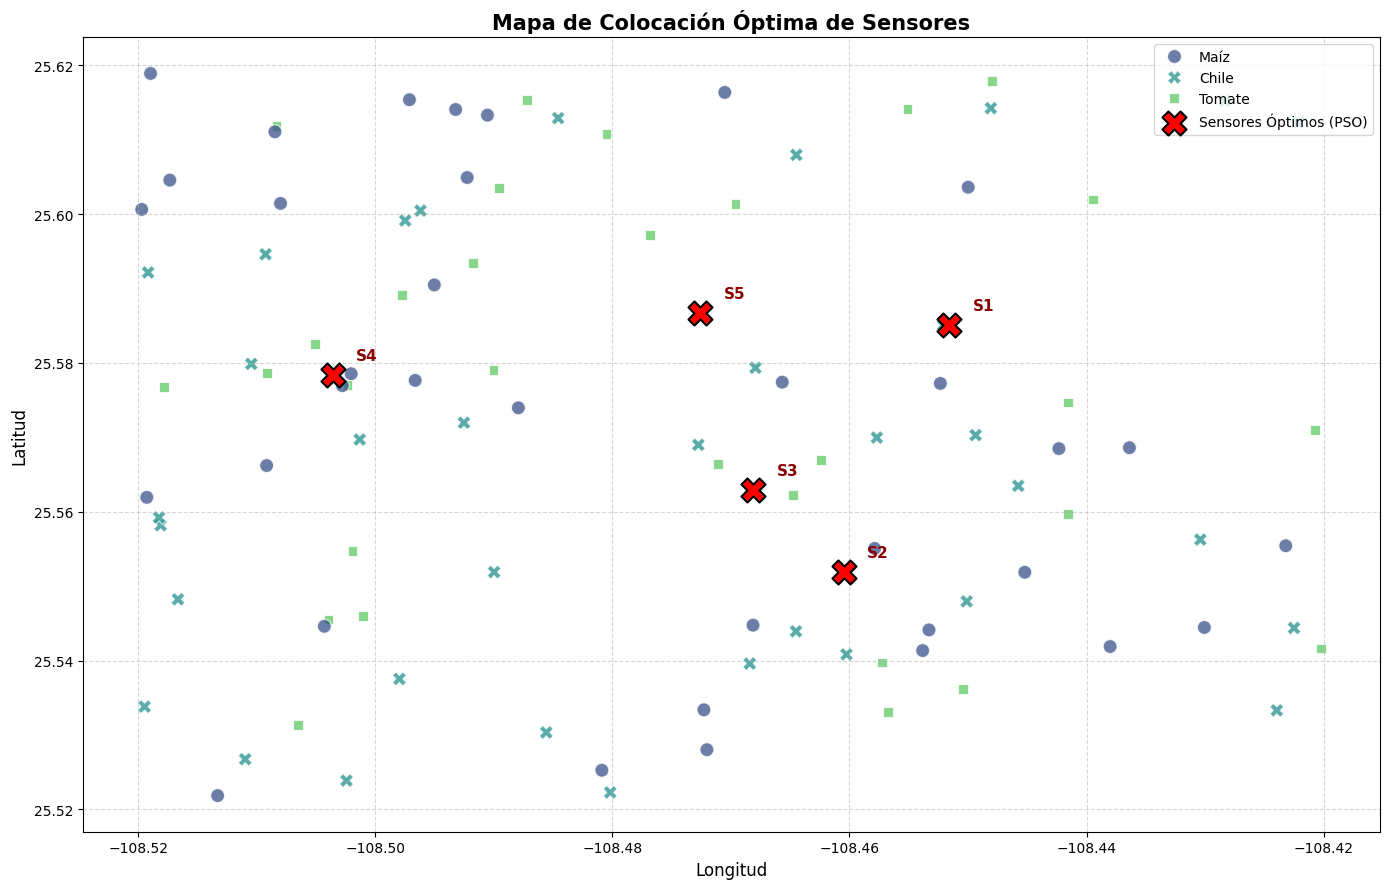

In [ ]:

#Mapa de los sensores optimizados
fig, ax = plt.subplots(figsize=(14, 9)) 

sns.scatterplot(
    data    = cargador.datos_originales,
    x       = 'Longitud',
    y       = 'Latitud',
    hue     = 'Cultivo',
    style   = 'Cultivo',
    s       = 100,
    alpha   = 0.75,
    palette = 'viridis',
    ax      = ax
)
ax.scatter(
    ubicaciones_optimas[col_lon],
    ubicaciones_optimas[col_lat],
    c          = 'red',
    marker     = 'X',
    s          = 300,
    label      = 'Sensores Óptimos (PSO)',
    edgecolors = 'black',
    linewidth  = 1.5,
    zorder     = 5
)

for _, row in ubicaciones_optimas.iterrows():
    ax.annotate(
        row['Sensor'],
        xy     = (row[col_lon], row[col_lat]),
        xytext = (row[col_lon] + 0.002, row[col_lat] + 0.002),
        fontsize   = 11,
        fontweight = 'bold',
        color      = 'darkred'
    )

ax.set_title('Mapa de Colocación Óptima de Sensores',
             fontsize=15, fontweight='bold')
ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud',  fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('mapa_sensores_optimos.png', dpi=150, bbox_inches='tight')
plt.show()

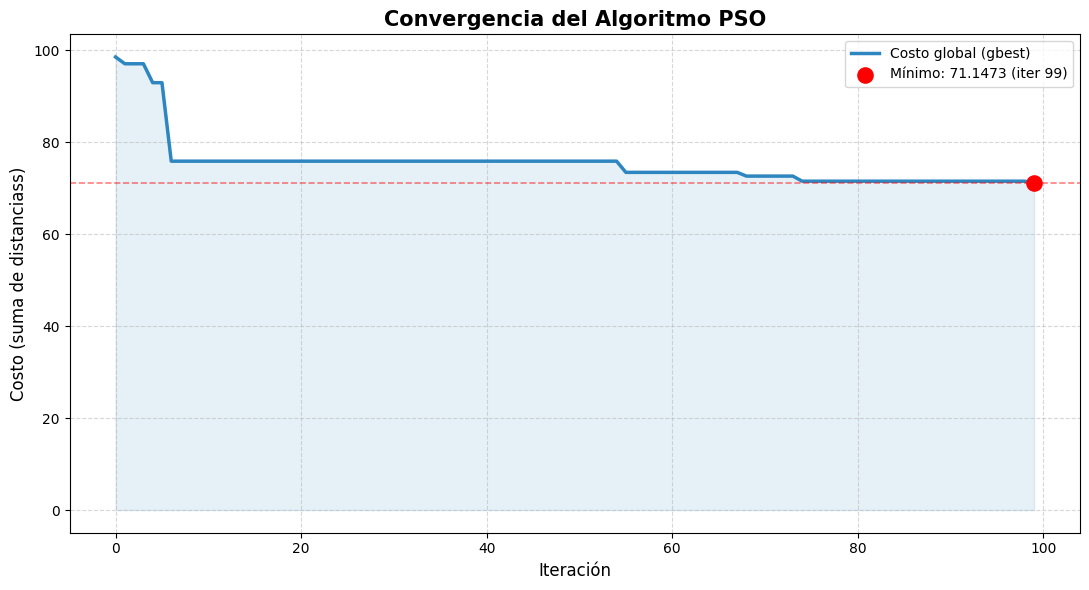

In [26]:
#Indagando mas sobre el PSO, podimos analizar que tambien podemos graficar la convergencia del algoritmo, es decir, como es
# que fue mejorando el enjambre con cada iteracion, lo cual podemos analizarlo de la siguiente forma:

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    optimizador.historial_costos,
    color     = '#2E86C1',
    linewidth = 2.5,
    label     = 'Costo global (gbest)'
)
ax.fill_between(
    range(len(optimizador.historial_costos)),
    optimizador.historial_costos,
    alpha = 0.12,
    color = '#2E86C1'
)

min_costo = min(optimizador.historial_costos)
min_iter  = optimizador.historial_costos.index(min_costo)
ax.scatter(
    min_iter, min_costo,
    color  = 'red',
    s      = 120,
    zorder = 5,
    label  = f'Mínimo: {min_costo:.4f} (iter {min_iter})'
)

ax.axhline(
    min_costo,
    color     = 'red',
    linestyle = '--',
    alpha     = 0.5,
    linewidth = 1.2
)

ax.set_title('Convergencia del Algoritmo PSO', fontsize=15, fontweight='bold')
ax.set_xlabel('Iteración', fontsize=12)
ax.set_ylabel('Costo (suma de distanciass)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('convergencia_pso.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#Terminado este algoritmo nos gustaria agregar que el PSO como en la vida real es un proceso que cada vez que se ejecuta
# puede dar resultados ligeramente diferentes, en nuestro proyecto no se vio de esa manera ya que usamos una semilla fija para
# garantizar que los resultados sean repoducibles, si se quisera experimentar con la varibilidad no se duda en conocer el algoritmo y eliminar
# dicha semilla fija.